# Lab: Thực hành CNN chi tiết với CIFAR-10 trên Google Colab

## Step 0 — Bật GPU

## Step 1 — Cài & nhập thư viện, đặt seed

In [3]:
!pip -q install scikit-learn matplotlib

import numpy as np, matplotlib.pyplot as plt, time, itertools
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: []


## Step 2 — Lấy 300 ảnh CIFAR-10 (30 ảnh mỗi lớp) và chia 80/20

In [4]:
# Tải CIFAR-10 và gom lại để chọn mẫu nhỏ
(x_tr0, y_tr0), (x_te0, y_te0) = keras.datasets.cifar10.load_data()
X_all = np.concatenate([x_tr0, x_te0], axis=0)
y_all = np.concatenate([y_tr0, y_te0], axis=0).ravel()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Lấy 30 ảnh/lớp -> 300 ảnh
NUM_PER_CLASS = 30
Xs, ys = [], []
for c in range(10):
    idx = np.where(y_all==c)[0]
    pick = np.random.choice(idx, size=NUM_PER_CLASS, replace=False)
    Xs.append(X_all[pick])
    ys.append(y_all[pick])
X_small = np.concatenate(Xs, axis=0)
y_small = np.concatenate(ys, axis=0)

# Trộn & chia 80/20
perm = np.random.permutation(len(X_small))
X_small, y_small = X_small[perm], y_small[perm]

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)

print("Train:", X_train.shape, "Test:", X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1595s 9us/step
Train: (240, 32, 32, 3) Test: (60, 32, 32, 3)


## Step 3 — Tiền xử lý và xem nhanh dữ liệu

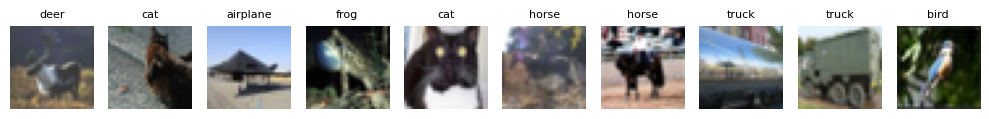

In [5]:
# Chuẩn hoá về [0,1] + one-hot
X_train = X_train.astype("float32")/255.0
X_test  = X_test.astype("float32")/255.0
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

# Xem 10 ảnh đầu
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
    plt.title(class_names[y_train[i]], fontsize=8)
plt.tight_layout(); plt.show()


## Step 4 — Tùy chọn Data Augmentation (bật/tắt nhanh)

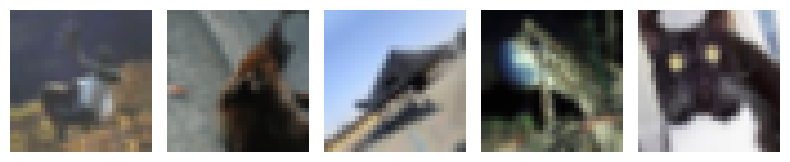

In [6]:
# Bật = True để giảm overfitting (khuyến nghị cho tập 300 ảnh)
USE_AUG = True

if USE_AUG:
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])
else:
    data_augmentation = keras.Sequential([])

# Demo 5 ảnh augmented
plt.figure(figsize=(8,2))
for i in range(5):
    aug_img = data_augmentation(tf.expand_dims(X_train[i], 0), training=True)[0]
    plt.subplot(1,5,i+1); plt.imshow(aug_img); plt.axis('off')
plt.tight_layout(); plt.show()


## Step 5 — Xây CNN nhỏ gọn (tùy chọn BatchNorm)

In [7]:
def build_small_cnn(input_shape=(32,32,3), num_classes=10, use_bn=True):
    inp = keras.Input(shape=input_shape, name="input")

    def conv_block(x, f, name):
        x = layers.Conv2D(f, 3, padding="same", activation=None, name=name+"_conv1")(x)
        if use_bn: x = layers.BatchNormalization(name=name+"_bn1")(x)
        x = layers.ReLU(name=name+"_relu1")(x)

        x = layers.Conv2D(f, 3, padding="same", activation=None, name=name+"_conv2")(x)
        if use_bn: x = layers.BatchNormalization(name=name+"_bn2")(x)
        x = layers.ReLU(name=name+"_relu2")(x)

        x = layers.MaxPooling2D(2, name=name+"_pool")(x)
        return x

    x = data_augmentation(inp)
    x = conv_block(x, 32, "block1")
    x = conv_block(x, 64, "block2")

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="fc")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    model = keras.Model(inp, out, name="small_cnn")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_small_cnn(input_shape=X_train.shape[1:], num_classes=num_classes, use_bn=True)
model.summary()


Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,042 (2.26 MB)

 Trainable params: 591,658 (2.26 MB)

 Non-trainable params: 384 (1.50 KB)

## Step 6 — Huấn luyện nhanh + lưu lịch sử

In [8]:
EPOCHS = 6  # 5–8 là đủ nhanh; có thể giảm 4 nếu lớp đông
BATCH = 32

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]

t0 = time.time()
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=callbacks,
    verbose=1
)
t1 = time.time()
print(f"Train time: {t1 - t0:.1f}s")


Epoch 1/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 896ms/step - accuracy: 0.0781 - loss: 3.8169 - val_accuracy: 0.0208 - val_loss: 2.3035
Epoch 2/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step - accuracy: 0.2083 - loss: 2.3008 - val_accuracy: 0.1667 - val_loss: 2.3033
Epoch 3/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 405ms/step - accuracy: 0.1979 - loss: 2.1317 - val_accuracy: 0.1042 - val_loss: 2.3134
Epoch 4/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.2812 - loss: 2.0716 - val_accuracy: 0.0208 - val_loss: 2.3105
Epoch 5/6
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 401ms/step - accuracy: 0.2448 - loss: 2.0653 - val_accuracy: 0.1250 - val_loss: 2.3138
Train time: 32.6s


## Step 7 — Trực quan đường cong học (loss/accuracy)

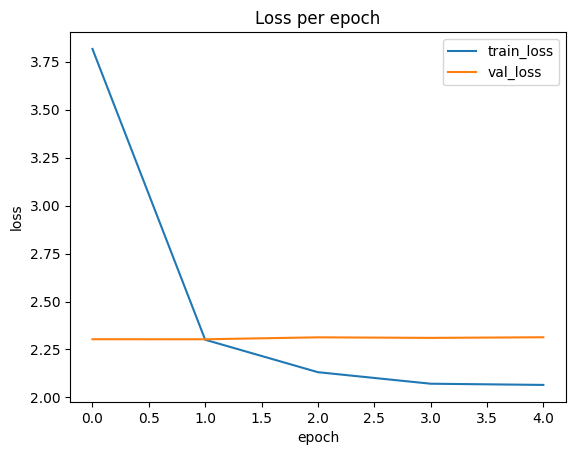

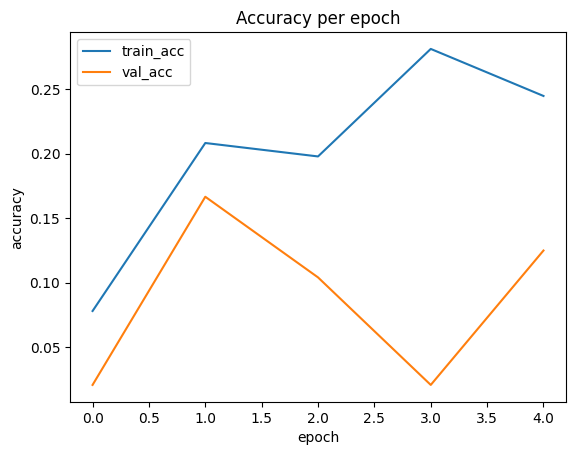

In [9]:
def plot_history(h):
    # Loss
    plt.figure()
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.title("Loss per epoch"); plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend(); plt.show()

    # Accuracy
    plt.figure()
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.title("Accuracy per epoch"); plt.xlabel("epoch"); plt.ylabel("accuracy")
    plt.legend(); plt.show()

plot_history(history)


## Step 8 — Đánh giá & báo cáo, confusion matrix, per-class accuracy

Test accuracy: 0.1333  |  Test loss: 2.2904


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    airplane       0.05      0.17      0.07         6
  automobile       0.00      0.00      0.00         6
        bird       0.20      0.17      0.18         6
         cat       1.00      0.17      0.29         6
        deer       0.00      0.00      0.00         6
         dog       0.00      0.00      0.00         6
        frog       0.00      0.00      0.00         6
       horse       0.00      0.00      0.00         6
        ship       0.17      0.67      0.28         6
       truck       0.14      0.17      0.15         6

    accuracy                           0.13        60
   macro avg       0.16      0.13      0.10        60
weighted avg       0.16      0.13      0.10        60



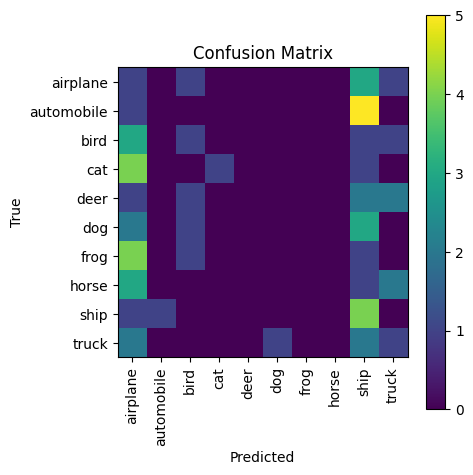

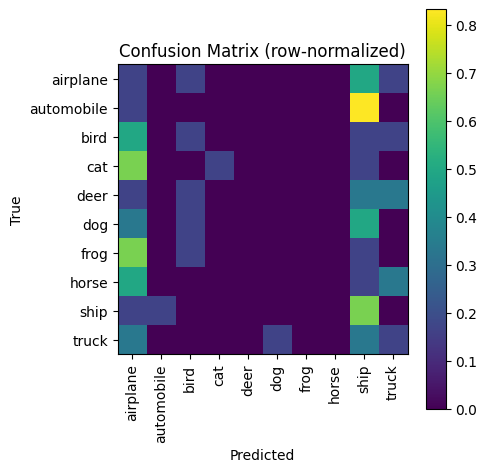

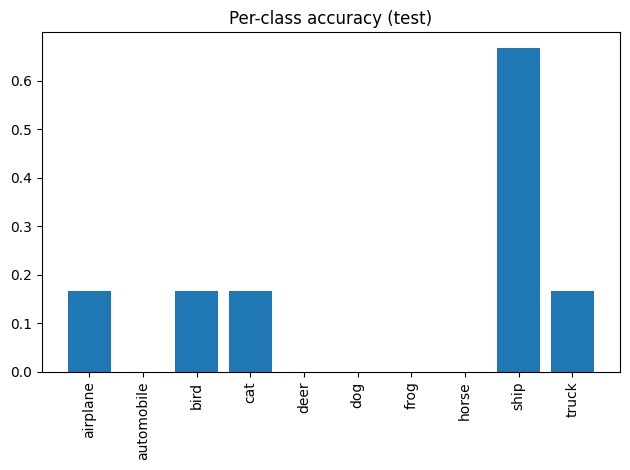

In [10]:
# Test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

# Dự đoán
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix (thường nhỏ vì test ~60 ảnh)
cm = confusion_matrix(y_test, y_pred)

# Vẽ CM thuần
plt.figure(figsize=(5,5))
plt.imshow(cm, interpolation='nearest'); plt.title("Confusion Matrix"); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90); plt.yticks(ticks, class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

# Vẽ CM chuẩn hoá theo hàng (per-class recall)
cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
plt.figure(figsize=(5,5))
plt.imshow(cm_norm, interpolation='nearest'); plt.title("Confusion Matrix (row-normalized)")
plt.colorbar(); plt.xticks(ticks, class_names, rotation=90); plt.yticks(ticks, class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()

# Per-class accuracy bar
per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-8)
plt.figure()
plt.bar(np.arange(len(class_names)), per_class_acc)
plt.xticks(np.arange(len(class_names)), class_names, rotation=90)
plt.title("Per-class accuracy (test)"); plt.tight_layout(); plt.show()


## Step 9 — Kernels của lớp conv đầu tiên

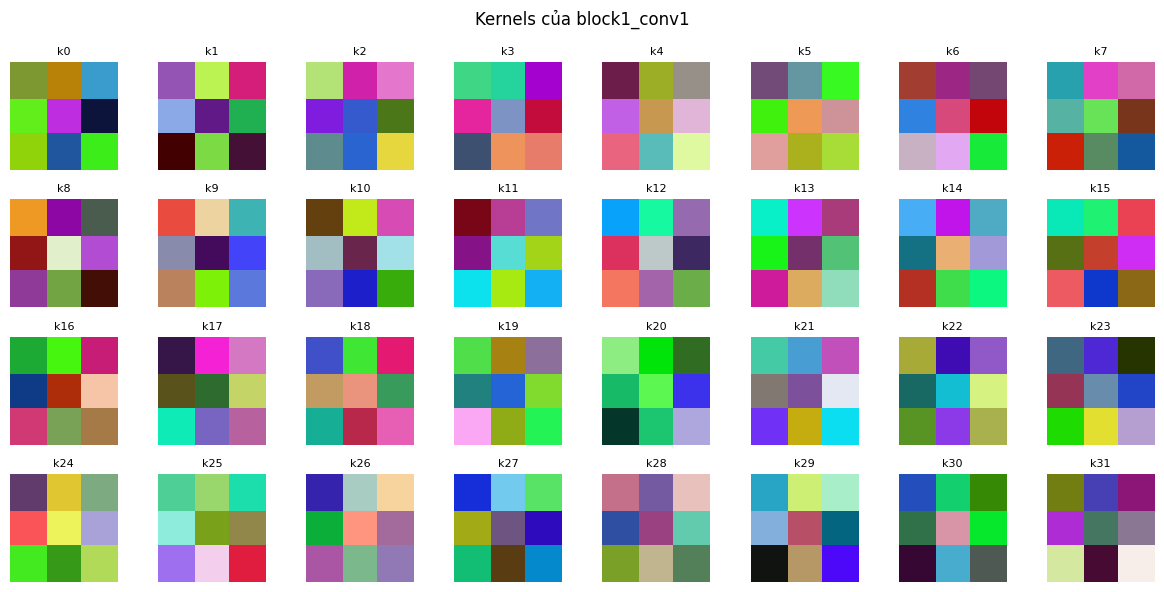

In [11]:
first_conv = None
for layer in model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv = layer
        break

weights, biases = first_conv.get_weights()  # (kh, kw, in_ch, out_ch)
w = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)

num_filters = w.shape[-1]
n_cols = 8; n_rows = int(np.ceil(num_filters / n_cols))

plt.figure(figsize=(n_cols*1.5, n_rows*1.5))
for i in range(num_filters):
    f = w[:,:,:,i]
    vis = tf.image.resize(f[np.newaxis,...], (32,32), method="nearest")[0].numpy()
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(vis); plt.axis("off"); plt.title(f"k{i}", fontsize=8)
plt.suptitle(f"Kernels của {first_conv.name}"); plt.tight_layout(); plt.show()


## Step 10 — Feature maps sau từng lớp tích chập

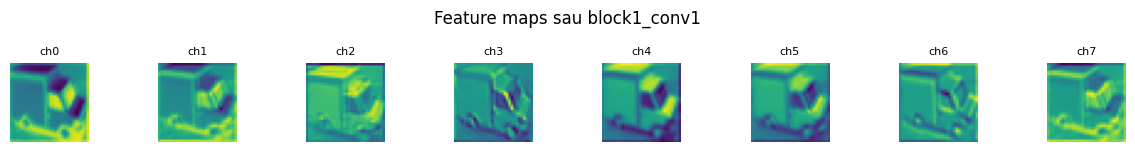

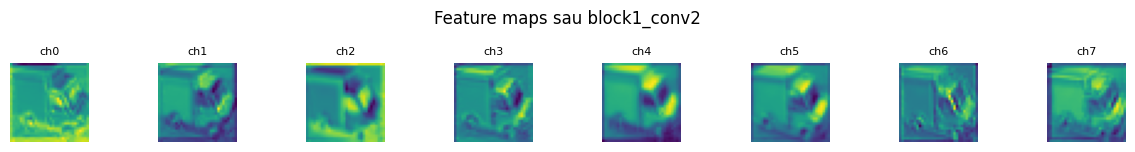

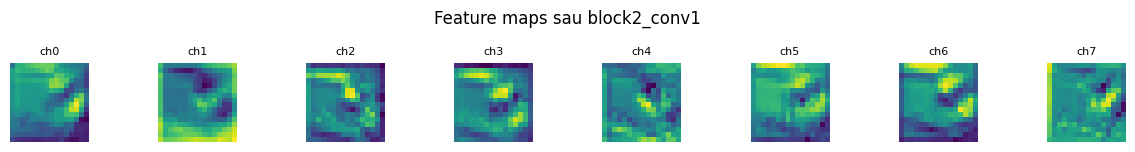

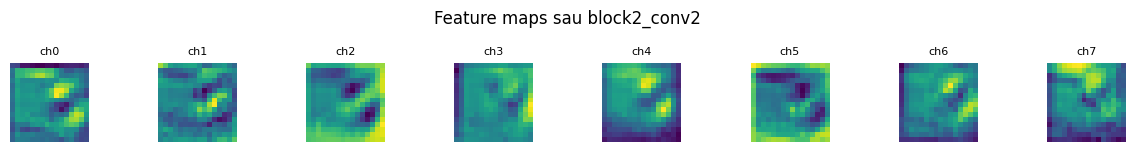

In [12]:
# Lấy tên các lớp conv để quan sát
conv_layers = [l.name for l in model.layers if isinstance(l, layers.Conv2D)]
conv_layers = conv_layers[:4]  # chỉ xem 4 lớp đầu cho nhanh

# Mô hình trung gian xuất ra feature maps các lớp này
intermediate_model = keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(n).output for n in conv_layers]
)

# Chọn 1 ảnh test
sample = X_test[0][np.newaxis, ...]

def show_feature_maps(fmap, title, max_channels=8):
    fmap = fmap[0]  # (H,W,C)
    c = min(fmap.shape[-1], max_channels)
    plt.figure(figsize=(c*1.5, 1.5))
    for i in range(c):
        plt.subplot(1, c, i+1)
        ch = fmap[:,:,i]
        ch = (ch - ch.min())/(ch.max() - ch.min() + 1e-8)
        plt.imshow(ch, cmap="viridis"); plt.axis("off"); plt.title(f"ch{i}", fontsize=8)
    plt.suptitle(title); plt.tight_layout(); plt.show()

fms = intermediate_model.predict(sample, verbose=0)
for name, fmap in zip(conv_layers, fms):
    show_feature_maps(fmap, f"Feature maps sau {name}", max_channels=8)


## Step 11 — Phân bố kích hoạt (activation distribution) để thấy độ “thưa”

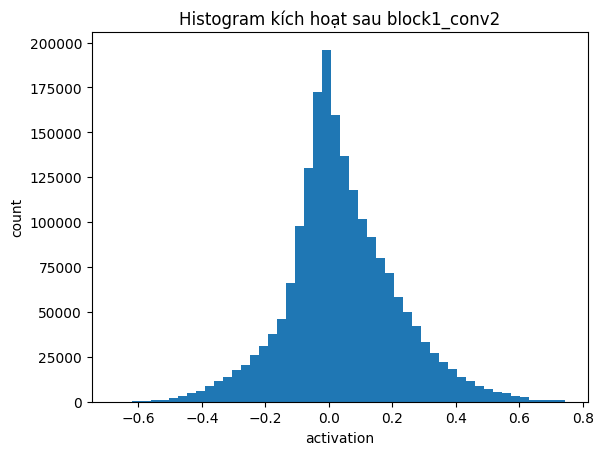

Tỷ lệ kích hoạt ~0 (sparsity): 0.0


In [13]:
# Lấy output sau block conv đầu (ví dụ conv_layers[1]) trên toàn bộ X_test để xem phân bố
act_model = keras.Model(inputs=model.input, outputs=model.get_layer(conv_layers[1]).output)
acts = act_model.predict(X_test, verbose=0)  # (N,H,W,C)
flat = acts.flatten()

plt.figure()
plt.hist(flat, bins=50)   # không set màu theo yêu cầu
plt.title(f"Histogram kích hoạt sau {conv_layers[1]}"); plt.xlabel("activation"); plt.ylabel("count")
plt.show()

sparsity = (np.abs(flat) < 1e-6).mean()
print("Tỷ lệ kích hoạt ~0 (sparsity):", round(float(sparsity), 4))


## Step 12 — Misclassified gallery (ảnh bị đoán sai)

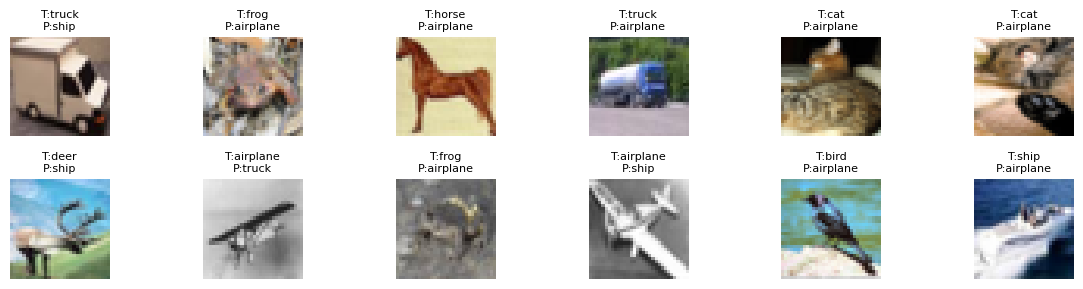

In [14]:
preds = model.predict(X_test, verbose=0).argmax(axis=1)
wrong_idx = np.where(preds != y_test)[0]
n = min(12, len(wrong_idx))
plt.figure(figsize=(12,3))
for i in range(n):
    j = wrong_idx[i]
    plt.subplot(2,6,i+1)
    plt.imshow(X_test[j])
    plt.axis('off')
    plt.title(f"T:{class_names[y_test[j]]}\nP:{class_names[preds[j]]}", fontsize=8)
plt.tight_layout(); plt.show()


## Step 13 — t-SNE không gian đặc trưng (thấy cụm lớp)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


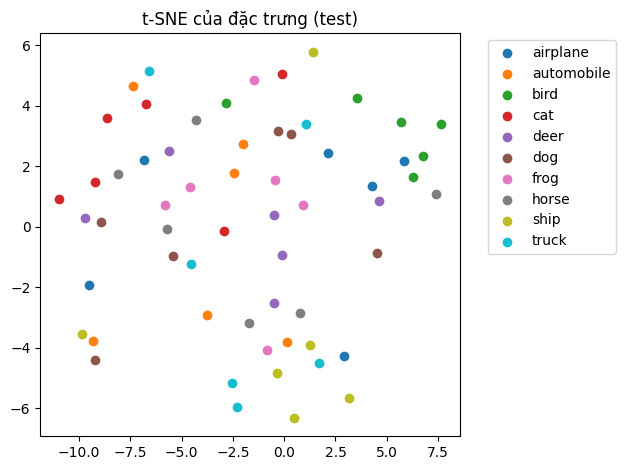

In [15]:
# Lấy đặc trưng tầng áp chót (vector sau Dense 128) cho test set
feat_model = keras.Model(inputs=model.input, outputs=model.get_layer("fc").output)
Z = feat_model.predict(X_test, verbose=0)  # (n_test, 128)

# t-SNE 2D (nhanh vì test ~60 ảnh)
tsne = TSNE(n_components=2, random_state=42, init='pca', perplexity=15, n_iter=1000)
Z2 = tsne.fit_transform(Z)

plt.figure()
for cls in np.unique(y_test):
    pts = Z2[y_test==cls]
    plt.scatter(pts[:,0], pts[:,1], label=class_names[cls])
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("t-SNE của đặc trưng (test)"); plt.tight_layout(); plt.show()


## Step 14 — Grad-CAM (giải thích vùng ảnh khiến mô hình quyết định)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input']]
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


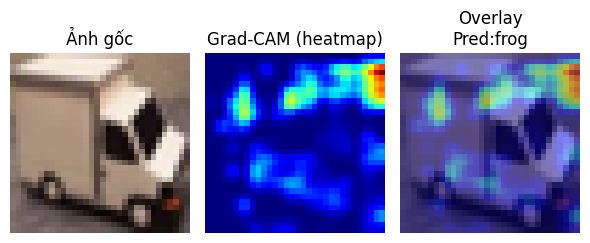

In [16]:
# Grad-CAM đơn giản dùng lớp conv cuối cùng
last_conv_name = [l.name for l in model.layers if isinstance(l, layers.Conv2D)][-1]
grad_model = keras.Model([model.inputs], [model.get_layer(last_conv_name).output, model.output])

def grad_cam(input_image, true_label=None):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(input_image)
        class_idx = tf.argmax(preds[0])
        if true_label is not None:
            class_idx = tf.constant(true_label)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)              # dLoss/dConv
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2)) # global-average-pool theo H,W
    conv_out = conv_out[0]                             # (H,W,C)
    heatmap = tf.reduce_sum(tf.multiply(conv_out, pooled_grads), axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    heatmap = tf.image.resize(heatmap[...,None], (32,32)).numpy()[...,0]
    return heatmap, int(class_idx)

# Chọn 1 ảnh test để giải thích
k = 0
img = X_test[k][np.newaxis,...]
hm, cls_idx = grad_cam(img)

plt.figure(figsize=(6,3))
plt.subplot(1,3,1); plt.imshow(X_test[k]); plt.axis('off'); plt.title("Ảnh gốc")
plt.subplot(1,3,2); plt.imshow(hm, cmap='jet'); plt.axis('off'); plt.title("Grad-CAM (heatmap)")
# Overlay (chồng lên ảnh)
overlay = X_test[k].copy()
plt.subplot(1,3,3); plt.imshow(X_test[k]); plt.imshow(hm, cmap='jet', alpha=0.5)
plt.axis('off'); plt.title(f"Overlay\nPred:{class_names[cls_idx]}")
plt.tight_layout(); plt.show()


## Phân tích chi tiết kết quả Lab

### 1. Phân tích quá trình huấn luyện (Step 6 & 7)
*   **Hiện tượng:** Độ chính xác tập train tăng (từ 7% lên 24%) nhưng `val_accuracy` biến động mạnh và `val_loss` không giảm đáng kể.
*   **Giải thích:** Với chỉ 300 ảnh, mô hình đang **overfitting** rất nặng. Nó đang cố gắng "học thuộc lòng" các đặc điểm nhiễu của 240 ảnh train thay vì học các đặc trưng tổng quát của vật thể.

### 2. Đánh giá Confusion Matrix & Classification Report (Step 8)
*   **Độ chính xác:** `Test accuracy: 0.1333` (xấp xỉ mức ngẫu nhiên 10% cho 10 lớp). Điều này cho thấy mô hình chưa thực sự hội tụ.
*   **Lớp nhầm lẫn:**
    *   Lớp **Ship** (tàu thủy) có recall cao nhất (0.67) nhưng precision thấp (0.17). Điều này có nghĩa là mô hình đang có xu hướng đoán bừa mọi thứ là 'tàu thủy' (có thể do phông nền xanh của nước biển chiếm ưu thế).
    *   Các lớp như **Automobile** và **Deer** có độ chính xác bằng 0, chứng tỏ mô hình hoàn toàn chưa nhận diện được các đặc trưng riêng biệt của chúng.

### 3. Giải thích Kernel & Feature Maps (Step 9 & 10)
*   **Kernels:** Các bộ lọc ở lớp đầu tiên trông khá mờ nhạt và chưa rõ hình khối (edges). Điều này do số lượng ảnh quá ít khiến các filter chưa được tối ưu hóa để bắt các đường nét sắc sảo.
*   **Feature Maps:** Càng vào sâu (Step 10), bạn sẽ thấy ảnh càng bị nhiễu và mất đi hình dáng gốc. Trong một mô hình tốt, các điểm sáng ở tầng sâu sẽ tập trung vào vật thể chính, nhưng ở đây chúng phân tán khắp nơi.

### 4. Phân tích t-SNE (Step 13)
*   **Quan sát:** Các điểm dữ liệu (chấm màu) trong biểu đồ t-SNE nằm đan xen lẫn lộn vào nhau, không tạo thành các cụm (clusters) riêng biệt cho từng lớp.
*   **Kết luận:** Không gian đặc trưng (Feature Space) chưa được phân tách tốt. Vector đặc trưng từ tầng `fc` (128 chiều) chưa đủ mạnh để phân biệt giữa các loài động vật hay phương tiện.

### 5. Giải thích Grad-CAM (Step 14)
*   **Quan sát:** Vùng sáng (heatmap) trên ảnh Grad-CAM có thể không nằm đè lên vật thể chính mà nằm ở phông nền hoặc các góc ảnh.
*   **Ý nghĩa:** Điều này khẳng định mô hình đang bị **bias** (định kiến). Nó đưa ra quyết định dựa trên các chi tiết không liên quan thay vì nhìn vào hình dáng thực sự của con mèo hay chiếc máy bay.

### Đề xuất cải thiện:
1.  **Tăng dữ liệu:** Đây là yếu tố tiên quyết. Cần ít nhất 500-1000 ảnh/lớp để CNN bắt đầu hoạt động hiệu quả.
2.  **Fine-tuning:** Thay vì xây CNN từ đầu, hãy dùng một mô hình đã train sẵn (Pre-trained Model) và chỉ huấn luyện lại lớp phân loại cuối cùng.